This notebook should serve as an extensible benchmark for methods predicting spatial cell counts from single cell data

## Setup

### Load Modules

In [1]:
from pathlib import Path
from typing import Callable, NamedTuple, List, Any, Optional, Sequence, TypeVar
from dataclasses import dataclass
from functools import reduce
from typing import TypeVar

import anndata as ad
from anndata import AnnData
import matplotlib.pyplot as plt
import numpy as np
from numpy.typing import NDArray
from numpy import ndarray
import pandas as pd
from pandas import DataFrame
import seaborn as sns
import scanpy as sc
import sklearn as sk
from tqdm import tqdm
import tangram as tg
from scipy.stats import pearsonr, spearmanr
from scipy.spatial.distance import cosine
from sklearn.decomposition import non_negative_factorization
from sklearn.metrics import mean_squared_error
from kneed import KneeLocator
import scvi
from scvi.model import SCVI

from disk_cache import disk_cache

### Data Utils

In [2]:


class Reconstruction_Result(NamedTuple):
    """
    A class to store the original and predicted gene counts along with methods
    to process and compute metrics based on those counts.

    Attributes:
        original_counts (pd.DataFrame): The original gene counts from the query data.
        predicted_counts (pd.DataFrame): The predicted gene counts from the gene prediction model.
    """

    original_counts: pd.DataFrame
    predicted_counts: pd.DataFrame

    @classmethod
    def from_gene_predictor(
        cls,
        adata_query: ad.AnnData,
        compidx: NDArray[np.str_],
        subidx: NDArray[np.str_],
        gene_predictor: Callable[[ad.AnnData, NDArray[np.str_], NDArray[np.str_]], np.ndarray],
    ) -> "Reconstruction_Result":
        """
        Creates a Reconstruction_Result instance from a gene prediction model.

        Args:
            adata_query: The AnnData object containing the query data (e.g., query spatial data).
            compidx: A numpy array of target genes for prediction
            subidx: A numpy array of input genes for prediction
            gene_predictor: A function that predicts gene counts
                based on the query AnnData object and the list of gene identifiers. It should return a NumPy array
                of predicted counts.

        Returns:
            Reconstruction_Result: A new instance containing the original and predicted gene counts as DataFrames.
        """
        return Reconstruction_Result( 
            pd.DataFrame(
                data=np.array(adata_query[:, compidx].X),
                columns=compidx,
                index=adata_query.obs.index
            ),
            pd.DataFrame(
                data=gene_predictor(adata_query, compidx, subidx),
                columns=compidx,
                index=adata_query.obs.index
            )
        )

    @classmethod
    def from_reconstruction_result_collection(
        cls,
        reconstruction_results: list["Reconstruction_Result"]
    ) -> "Reconstruction_Result":
        genes = reduce(lambda x, y: set.union(x, y), [set(reconstruction_result.predicted_counts.columns) for reconstruction_result in reconstruction_results])
        predicted_counts = pd.DataFrame()
        original_counts = pd.DataFrame()
        for gene in genes:
            predicted_counts[gene] = np.array([reconstruction_result.predicted_counts[gene].values for reconstruction_result in reconstruction_results if gene in reconstruction_result.predicted_counts.columns]).mean(axis=0)
            original_counts[gene] = np.array([reconstruction_result.original_counts[gene].values for reconstruction_result in reconstruction_results if gene in reconstruction_result.original_counts.columns]).mean(axis=0)
        return Reconstruction_Result(
            original_counts=original_counts,
            predicted_counts=predicted_counts
        )

    T = TypeVar("T")
    def compute_correlation(
        self,
        correlation_func: Callable[[np.ndarray, np.ndarray], T],
    ) -> T:
        """
        Computes the correlation between the original and predicted gene counts.

        Args:
            correlation_func (Callable[[np.ndarray, np.ndarray], float]): A function that computes the correlation
                between two NumPy arrays. It should return a single floating-point value representing the correlation.

        Returns:
            float: The computed correlation between the original and predicted gene counts.
        """
        return correlation_func(
            self.original_counts.values,
            self.predicted_counts.values
        )
    


T = TypeVar("T")
def transform_correlation_func(
    correlation_func: Callable[[np.ndarray, np.ndarray], T], 
    transform: Callable[[np.ndarray], np.ndarray] = lambda x: x
) -> Callable[[np.ndarray, np.ndarray], T]:
    """
    Returns a correlation function that applies a transformation to inputs before computing correlation.
    """
    return lambda x, y: correlation_func(transform(x), transform(y))

def benchmark_gene_predictor(
    adata_query: ad.AnnData,
    benchmarking_genes: list[NDArray],
    n_compidx: int,
    gene_predictor: Callable[[ad.AnnData, NDArray[np.str_], NDArray[np.str_]], NDArray]
) -> List[Reconstruction_Result]:
    """
    Benchmarks a gene prediction model by evaluating its performance across multiple randomized gene sets.

    This function identifies shared genes between the query and reference datasets, 
    generates multiple random permutations of these genes, and evaluates the given gene predictor 
    using subsets of genes as input and output.

    Args:
        adata_query (ad.AnnData): The query AnnData object containing the spatial gene expression data.
        benchmarking_genes (list[NDArray]): The shuffled gene matrix used to benchmark
        n_compidx (int): The number of genes to use as input (compidx, target genes) in each benchmark run.
        gene_predictor (Callable[[ad.AnnData, NDArray[np.str_], NDArray[np.str_]], Reconstruction_Result]): 
            A function that predicts gene expression of a given target gene subset given a query dataset an input gene subset.

    Returns:
        List[Reconstruction_Result]: A list of Reconstruction_Result objects, each containing 
        the original and predicted gene expression values for a given permutation.
    """


    return [
        Reconstruction_Result.from_gene_predictor(adata_query, gene_arr[:n_compidx], gene_arr[n_compidx:], gene_predictor)
        for gene_arr in tqdm(benchmarking_genes)
    ]


### NMF Utils

In [3]:
@disk_cache(Path("data/cache/benchmarking_different_predictors/non_negative_factorization_cached/"))
def non_negative_factorization_cached(*args, **kwargs) -> tuple[ndarray[Any, Any], ndarray[Any, Any], int]:
    """Cached wrapper for non-negative matrix factorization."""
    return non_negative_factorization(*args, **kwargs)

def select_optimal_components(
    X: NDArray[Any],
    n_components_range: list[int],
    *args: Any,
    **kwargs: Any
) -> Optional[int]:
    """
    Select the optimal number of NMF components by computing reconstruction error (MSE)
    for each candidate, then finding the 'knee' point on the error curve.

    Args:
        X (NDArray): Input data matrix to factorize (non-negative values).
        n_components_range (list[int]): List of candidate numbers of components to test.
        *args, **kwargs: Additional arguments passed to `KneeLocator`.

    Returns:
        Optional[int]: The number of components at the knee of the MSE curve, or None if no knee is found.
    """

    def locate_knee(
        x: Sequence[float],
        y: Sequence[float],
    ) -> Optional[int]:
        """Identify the knee point on a curve."""
        knee: Any | None = KneeLocator(x, y, *args, **kwargs).knee
        return int(knee) if knee is not None else None

    def compute_mse_for_n(n: int) -> float:
        """Compute the reconstruction MSE for a given number of components."""
        W, H, _ = non_negative_factorization_cached(X, n_components=n)
        X_hat: NDArray[Any] = W @ H
        return float(mean_squared_error(X, X_hat))

    MSEs: list[float] = [compute_mse_for_n(n) for n in n_components_range]
    knee: Optional[int] = locate_knee(n_components_range, MSEs)
    return knee

def initialize_nmf_factors_from_clustering(
    adata: AnnData,
    n_clusters: int
) -> tuple[NDArray[np.float64], NDArray[np.float64]]:
    """
    Initialize W and H matrices for NMF using cluster-specific ranked gene scores.

    This function clusters the input `AnnData` object using Leiden clustering,
    finds the resolution that yields the desired number of clusters, ranks genes 
    per cluster, and constructs:
    - W: A matrix of gene scores (non-negative)
    - H: One-hot encoded cluster membership per cell, with small non-zero entries
    
    Parameters:
        adata (AnnData): The input AnnData object.
        n_clusters (int): Desired number of clusters for initialization.

    Returns:
        Tuple[np.ndarray, np.ndarray]: W and H matrices for NMF initialization.
    """
    
    T = TypeVar("T")

    def find_input_for_output(
        f: Callable[[float], T],
        g: Callable[[T], int],
        target: int,
        max_iter: int = 500
    ) -> T:
        """Binary-like recursive search for an input that makes g(f(x)) == target."""

        def search(x: float, lower: Optional[float], upper: Optional[float], iter: int) -> T:
            t: T = f(x)
            value: int = g(t)

            if iter >= max_iter:
                raise RuntimeError("Maximum search iterations reached without convergence.")
            if value == target:
                return t

            match value > target, lower, upper:
                case (True, None, _):
                    return search(x / 2, lower, x, iter + 1)
                case (True, _, _):
                    assert lower is not None
                    return search((lower + x) / 2, lower, x, iter + 1)
                case (False, _, None):
                    return search(x * 2, x, upper, iter + 1)
                case (False, _, _):
                    assert upper is not None
                    return search((x + upper) / 2, x, upper, iter + 1)

        return search(1.0, None, None, 0)

    adata_copy: AnnData = adata.copy()
    sc.pp.normalize_total(adata_copy)
    sc.pp.log1p(adata_copy)
    sc.tl.pca(adata_copy)
    sc.pp.neighbors(adata_copy)

    result: AnnData = find_input_for_output(
        f=lambda x: sc.tl.leiden(adata_copy, resolution=x, copy=True),
        g=lambda adata: adata.obs["leiden"].nunique(),
        target=n_clusters
    )

    sc.tl.rank_genes_groups(result, 'leiden')

    W = pd.get_dummies(result.obs["leiden"], dtype="float").replace(0, 0.1).values
    H: NDArray[Any] = (lambda arr: np.where(arr < 0, 0.1, arr))(
        pd.concat(
            [sc.get.rank_genes_groups_df(result, index).set_index("names")["scores"] for index in list(result.uns["rank_genes_groups"]["names"].dtype.names)], 
            axis=1
        ).reindex(result.var.index).values
    ).T
    return W, H

def prepare_H_init(
    adata_reference: ad.AnnData,
    n_components: int
) -> pd.DataFrame:
    """
    Computes the initial H matrix for NMF using reference gene expression data.
    Args:
        adata_reference (ad.AnnData): Reference AnnData object.
        shared_genes (np.ndarray): Array of shared gene names.
        n_components (int): Number of NMF components.
    Returns:
        pd.DataFrame: Initial H matrix with genes as columns.
    """
    _, H_init, _ = non_negative_factorization(
        adata_reference.X,
        n_components=n_components
    )
    return pd.DataFrame(data=H_init, columns=adata_reference.var_names)


def predict_genes_nmf(
    adata_query: sc.AnnData, 
    H_init: pd.DataFrame,
    subidx: NDArray[np.str_],
) -> NDArray:
    """
    Predicts gene expression using NMF with a fixed H matrix.

    Args:
        adata_query: Query AnnData object.
        H_init: Precomputed H matrix from NMF.
        compidx: Array of target gene names.
        subidx: Array of input gene names.

    Returns:
        np.ndarray: Predicted expression values for compidx genes.
    """
    W, _, _ = non_negative_factorization(
        np.array(adata_query[:, subidx].X), 
        H=H_init[subidx].values,
        init="custom", 
        update_H=False,
        n_components=H_init.shape[0],
    )
    return W @ H_init.values

#### Architecture

In [4]:
def ReLU(Z: NDArray):
    return np.maximum(0, Z)

def ReLU_backward(dZ, Z):
    dZ[Z <= 0] = 0
    return dZ

@dataclass
class AffineLayer:
    W: np.ndarray
    b: np.ndarray

    def __post_init__(self):
        self.dW = np.zeros_like(self.W)
        self.db = np.zeros_like(self.b)
        self.input_cache = None  

    def forward(self, Z):
        self.input_cache = Z 
        return (Z @ self.W) + self.b
    
    def backward(self, dZ):
        dW = self.input_cache.T @ dZ  
        db = np.sum(dZ, axis=0, keepdims=True)  

        dZ_prev = dZ @ self.W.T 

        self.dW = dW
        self.db = db

        return dZ_prev 
    
    def __call__(self, Z):
        return self.forward(Z)

class Model:
    def __init__(self, n_input: int, n_latent: int, n_output: int):
        self.fc1 = AffineLayer(
            W=np.random.randn(n_input, n_latent) * \
                np.sqrt(2 / (n_input + n_latent)),
            b=np.zeros((1, n_latent))
        )
        self.fc2 = AffineLayer(
            W=np.random.randn(n_latent, n_output) * \
                np.sqrt(2 / (n_latent + n_output)),
            b=np.zeros((1, n_output))
        )

    def forward(self, Z):
        self.Z1 = self.fc1(Z)  
        self.A1 = ReLU(self.Z1)
        self.Z2 = self.fc2(self.A1) 
        return self.Z2

    def backward(self, dZ2):
        """Backpropagate gradients through the network."""
        dA1 = self.fc2.backward(dZ2)
        dZ1 = ReLU_backward(dA1, self.Z1)
        dX = self.fc1.backward(dZ1)
        return dX 

    def update_parameters(self, lr=0.01):
        """Update parameters using gradient descent."""
        self.fc1.W -= lr * self.fc1.dW
        self.fc1.b -= lr * self.fc1.db
        self.fc2.W -= lr * self.fc2.dW
        self.fc2.b -= lr * self.fc2.db

    def __call__(self, Z):
        return self.forward(Z)

    def train(
        self,
        data,
        n_epochs,
        learning_rate
    ):
        for _ in tqdm(range(n_epochs)):
            pass


#### Predictor

### Tangram Utils

In [5]:
from numpy import str_


@disk_cache(Path("data/cache/benchmarking_different_predictors/predict_genes_tangram"))
def predict_genes_tangram(
    adata_query: sc.AnnData,
    adata_reference: sc.AnnData,
    compidx: NDArray[np.str_], 
    subidx: NDArray[np.str_],
    *args,
    **kwargs
) -> NDArray:
    """
    Predicts gene expression using Tangram.

    Args:
        adata_query: Query AnnData object.
        adata_reference: Reference AnnData object.
        compidx: Array of target gene names.
        subidx: Array of input gene names.
        *args: arguments for tg.map_cells_to_space
        **args: keyword arguments for tg.map_cells_to_space

    Returns:
        np.ndarray: Predicted expression values for compidx genes.
    """
    markers: NDArray[str_] = np.hstack([compidx, subidx])
    #adata_reference = adata_reference[:, markers]
    adata_reference = adata_reference.copy()
    adata_query_subidx: AnnData = adata_query[:, subidx]
    tg.pp_adatas(
        adata_reference, adata_query_subidx
    )
    ad_map = tg.map_cells_to_space(
        adata_sc=adata_reference,
        adata_sp=adata_query_subidx,
        *args,
        **kwargs
    )
    # Necessary because tangram lowercases all gene names
    compidx_lower = np.array(
        [gene.lower() for gene in compidx]
    )
    ad_ge = tg.project_genes(ad_map, adata_reference)
    return np.array(ad_ge[:, compidx_lower].X)

### Load Data

'BZE'
'Blood vasc.'
'Cycling/GC B cell'
'Glial'
'Goblet'
'Lymphatic'
'MZE'
'Macrophage'
'Paneth'
'Plasma'
'Rest B'
'Stem/TA'
'Stroma'
'T cell'
'TZE'
'Tuft'
'cDC/monocyte'
'neurons/enteroendocrine'
'pDC'

In [6]:
celltype = None#'Stem/TA'
n_predicted_genes = 10

def _adata_sp(celltype: Optional[str] = None) -> AnnData:
    adata_sp: AnnData = sc.read(
        Path.cwd() / "data" / "inputQuery" / "gene_by_cell.csv",
    ).transpose()
    obs: DataFrame = sc.read_h5ad(Path.cwd() / "data" / "nico_out" / "nico_celltype_annotation.h5ad").obs
    adata_sp.obs = obs
    adata_sp.obs["celltype"] = adata_sp.obs["nico_ct"]
    if celltype:
        adata_sp = adata_sp[adata_sp.obs["celltype"] == celltype]
    return adata_sp



def _adata_sc(celltype: Optional[str] = None) -> AnnData:
    adata_sc: AnnData = sc.read_h5ad(Path.cwd() / "data" / "inputRef" / "input_ref.h5ad")
    adata_sc.obs["celltype"] = adata_sc.obs["cluster"]
    if celltype:
        adata_sc = adata_sc[adata_sc.obs["celltype"] == celltype]
    return adata_sc



adata_sp: AnnData = _adata_sp(celltype)
adata_sc: AnnData = _adata_sc(celltype)

sc.pp.filter_genes(adata_sp, min_counts=1)
sc.pp.filter_genes(adata_sc, min_counts=1)

print(f"{adata_sp=}\n{adata_sc=}")

adata_sp=AnnData object with n_obs × n_vars = 7416 × 241
    obs: 'umi_sct', 'log_umi_sct', 'gene_sct', 'log_gene_sct', 'umi_per_gene_sct', 'log_umi_per_gene_sct', 'leiden0.4', 'leiden0.5', 'nico_ct', 'celltype'
    var: 'n_counts'
adata_sc=AnnData object with n_obs × n_vars = 2239 × 21197
    obs: 'cluster', 'celltype'
    var: 'n_counts'


In [7]:

adata_sc.X = adata_sc.X.toarray()

In [8]:
query_genes, _ = sc.pp.filter_genes(adata_sc, min_cells=1, inplace=False) # type: ignore
assert isinstance(query_genes, np.ndarray)
reference_genes, _ = sc.pp.filter_genes(adata_sp, min_cells=1, inplace=False) # type: ignore
assert isinstance(reference_genes, np.ndarray)
    
shared_genes = np.array(sorted(
    list(set(adata_sc.var_names[query_genes]).intersection(set(adata_sp.var_names[reference_genes])))
))
print(len(shared_genes))

203


## Main

In [9]:
benchmarking_genes = [np.random.default_rng(seed=seed).permutation(shared_genes) for seed in range(25)]
compidx, subidx = (lambda arr, n: (arr[:n], arr[n:]))(np.random.permutation(shared_genes), 10)

In [10]:
results = {}

### NMF

In [11]:
n_components = 3
H_init = prepare_H_init(adata_sc, n_components=n_components)

def nmf_predictor(
    adata_query: AnnData,
    compidx: ndarray,
    subidx: ndarray
):
    predicted_genes = predict_genes_nmf(
        adata_query,
        H_init,
        subidx
    )
    return predicted_genes[:, H_init.columns.get_indexer_for(compidx)]

results[f"NMF {n_components} components"] = benchmark_gene_predictor(adata_sp, benchmarking_genes, n_predicted_genes, nmf_predictor)

100%|██████████| 25/25 [00:02<00:00,  8.84it/s]


In [12]:
# For all methods, the "predictor" has to be a function that takes the query dataset, the genes to be predicted and the genes used for prediction and return the predicted counts as a numpy array
knee: int | None = select_optimal_components(adata_sc.X, list(range(2, 15)), curve="convex", direction="decreasing", S=1)

if knee is None:
    raise ValueError("Knee not found")

n_components = 3
H_init = prepare_H_init(adata_sc, n_components=knee)

def nmf_predictor(
    adata_query: AnnData,
    compidx: ndarray,
    subidx: ndarray
):
    predicted_genes = predict_genes_nmf(
        adata_query,
        H_init,
        subidx
    )
    return predicted_genes[:, H_init.columns.get_indexer_for(compidx)]

results[f"NMF\n+ Knee {knee}"] = benchmark_gene_predictor(adata_sp, benchmarking_genes, n_predicted_genes, nmf_predictor)
print(f"{knee=}")

100%|██████████| 25/25 [00:02<00:00,  8.65it/s]

knee=5


In [13]:

W_cluster, H_cluster = initialize_nmf_factors_from_clustering(adata_sc, knee)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [14]:
# Potential problems: leiden is unable to create the number of desired clusters, or rank genes is unable to calculate the statistics due to lack of samples
W_cluster, H_cluster = initialize_nmf_factors_from_clustering(adata_sc, knee)

_, H_init, _ = non_negative_factorization(
    adata_sc.X, 
    W=W_cluster.astype(adata_sc.X.dtype).copy(order="C"),
    H=H_cluster.astype(adata_sc.X.dtype).copy(order="C"),
    init="custom"
)
H_init = pd.DataFrame(data=H_init, columns=adata_sc.var_names)

def nmf_predictor(
    adata_query: AnnData,
    compidx: ndarray,
    subidx: ndarray
):
    predicted_genes = predict_genes_nmf(
        adata_query,
        H_init,
        subidx
    )
    return predicted_genes[:, H_init.columns.get_indexer_for(compidx)]

results[f"NMF\n+ Knee {knee}\n + Cluster"] = benchmark_gene_predictor(adata_sp, benchmarking_genes, n_predicted_genes, nmf_predictor)

100%|██████████| 25/25 [00:03<00:00,  8.12it/s]


### Tangram

In [23]:
def tangram_predictor(adata_query, compidx, subidx):
    return predict_genes_tangram(adata_query, adata_sc, compidx, subidx, device="mps", verbose=False)

results["Tangram"] = benchmark_gene_predictor(adata_sp, benchmarking_genes, n_predicted_genes, tangram_predictor)















































































100%|██████████| 25/25 [00:08<00:00,  2.97it/s]


### Autoencoder

In [16]:
@disk_cache(Path("data/cache/benchmarking_different_predictors/train_autoencoder/"))
def train_autoencoder(Y, latent_dim: int) -> Model:
    model = Model(len(shared_genes), latent_dim, len(shared_genes))
    for _ in tqdm(range(500)):
        Y_pred = model(Y)
        dY = 2 * (Y_pred - Y) / \
            Y.shape[0]
        model.backward(dY)
        model.update_parameters(lr=0.01)
    return model

In [17]:
Y = adata_sc[:, shared_genes].X
model: Model = train_autoencoder(Y, n_components)

autoencoder_predictor = lambda adata_query, compidx, subidx: \
    ReLU(
        model(
        adata_query[:, shared_genes].X
        )[:, pd.Index(shared_genes).get_indexer_for(compidx)]
    )

#def autoencoder_predictor(adata_query, compidx, subidx):
#    ReLU(model(
#        adata_query[:, shared_genes].X
#    )[:, pd.Index(shared_genes).get_indexer(compidx)])

results[f"Autoencoder latent dim {n_components}"] = benchmark_gene_predictor(adata_sp, benchmarking_genes, n_predicted_genes, autoencoder_predictor)

  3%|▎         | 16/500 [00:00<00:03, 151.56it/s]

100%|██████████| 25/25 [00:00<00:00, 71.50it/s]


In [18]:
Y = adata_sc[:, shared_genes].X
if knee is None:
    raise ValueError("Knee not found")
model: Model = train_autoencoder(Y, knee)

def autoencoder_predictor(
        adata_query: AnnData,
        compidx: ndarray,
        subidx: ndarray,
) -> ndarray:
    output = model(adata_query[:, shared_genes].X)[:, pd.Index(shared_genes).get_indexer_for(compidx)]
    return ReLU(output)

results[f"Autoencoder\n+ Knee {knee}"] = benchmark_gene_predictor(adata_sp, benchmarking_genes, n_predicted_genes, autoencoder_predictor)

  0%|          | 0/500 [00:00<?, ?it/s]

100%|██████████| 25/25 [00:00<00:00, 85.82it/s]


### NN Predictor

In [24]:
@disk_cache(Path("data/cache/benchmarking_different_predictors/nn_predictor/"))
def nn_predictor(
    adata_query: AnnData,
    compidx: ndarray,
    subidx: ndarray,
):
    model = Model(len(subidx), knee, adata_sc.n_vars)
    y_out = adata_sc.X
    for _ in range(200):
        Y_pred = model(adata_sc[:, subidx].X)
        dY = 2 * (Y_pred - y_out) / y_out.shape[0]
        model.backward(dY)
        model.update_parameters(lr=0.01)
    return ReLU(model(adata_query[:, subidx].X)[:, adata_sc.var_names.get_indexer_for(compidx)])

results[f"NN\n+ Knee {knee}"] = benchmark_gene_predictor(adata_sp, benchmarking_genes, n_predicted_genes, nn_predictor)















































































100%|██████████| 25/25 [21:11<00:00, 50.84s/it]


### SCVI

In [25]:
@disk_cache(Path("data/cache/benchmarking_different_predictors/train_scvi/"))
def train_scvi(adata: AnnData) -> SCVI:
    adata = adata.copy()
    scvi.model.SCVI.setup_anndata(adata)
    model = scvi.model.SCVI(adata)
    model.train(accelerator="mps")
    return model

scvi_vae: SCVI = train_scvi(adata_sc[:, shared_genes])

def scvi_VAE_predictor(
    adata_query,
    compidx,
    subidx
):
    output = scvi_vae.get_normalized_expression(adata_query[:, shared_genes].copy())
    return output[compidx].values

results[f"scvi VAE"] = benchmark_gene_predictor(adata_sp, benchmarking_genes, n_predicted_genes, scvi_VAE_predictor)

INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


...

INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             





100%|██████████| 25/25 [00:04<00:00,  5.50it/s]


### Correlation metrics

In [26]:
# The functions defined here have to return a single float to work
mean_genes = lambda x: np.nan_to_num(x.mean(axis=0))


pearsonr_mean = transform_correlation_func(
    lambda x, y: float(pearsonr(x, y)[0]), 
    mean_genes
)

pearsonr_log_mean = transform_correlation_func(
    lambda x, y: float(pearsonr(x, y)[0]), 
    lambda x: np.log(mean_genes(x) + 1e-3)
)

spearmanr_mean = transform_correlation_func(
    lambda x, y: float(spearmanr(x, y)[0]), 
    mean_genes
)

cosine_mean = transform_correlation_func(
    lambda x, y: 1 - float(cosine(x, y)),
    mean_genes
)

cosine_log_mean = transform_correlation_func(
    lambda x, y: 1 - float(cosine(x, y)),
    lambda x: np.log(mean_genes(x) + 1) # + 1 in this case to ensure values stay positive
)

log_mean_squared_error = transform_correlation_func(
    lambda x, y: float(mean_squared_error(x, y)),
    lambda x: np.log(x + 1e-3)
)

pearsonr_cells = transform_correlation_func(
    lambda x, y: np.nan_to_num(pearsonr(x, y)[0]),
    lambda x: x.T
)
pearsonr_genes = transform_correlation_func(
    lambda x, y: np.nan_to_num(pearsonr(x, y)[0]),
    lambda x: x
)

spearman_cells = transform_correlation_func(
    lambda x, y: np.array([float(spearmanr(x[:, i], y[:, i])[0]) for i in range(x.shape[1])]),
    lambda x: x.T
)
spearman_genes = transform_correlation_func(
    lambda x, y: np.array([float(spearmanr(x[:, i], y[:, i])[0]) for i in range(x.shape[1])]),
    lambda x: x
)
cosine_cells = transform_correlation_func(
    lambda x, y: np.array([1 - float(cosine(arr1, arr2)) for arr1, arr2 in zip(x.T, y.T)]),
    lambda x: x.T
)
cosine_genes = transform_correlation_func(
    lambda x, y: np.array([1 - float(cosine(arr1, arr2)) for arr1, arr2 in zip(x.T, y.T)]),
    lambda x: x
)

pearsonr_log_cells = transform_correlation_func(
    lambda x, y: np.nan_to_num(pearsonr(x, y)[0]),
    lambda x: np.log(x.T + 1e-3)
)
pearsonr_log_genes = transform_correlation_func(
    lambda x, y: np.nan_to_num(pearsonr(x, y)[0]),
    lambda x: np.log(x + 1e-3)
)

cosine_log_cells = transform_correlation_func(
    lambda x, y: np.array([1 - float(cosine(arr1, arr2)) for arr1, arr2 in zip(x.T, y.T)]),
    lambda x: np.log(x.T + 1e-3)
)
cosine_log_genes = transform_correlation_func(
    lambda x, y: np.array([1 - float(cosine(arr1, arr2)) for arr1, arr2 in zip(x.T, y.T)]),
    lambda x: np.log(x + 1e-3)
)

mse = transform_correlation_func(mean_squared_error, lambda x: x)
mse_log = transform_correlation_func(mean_squared_error, lambda x: np.log(np.nan_to_num(x) + 1e-3))


## Plot

In [28]:
print(celltype)

None


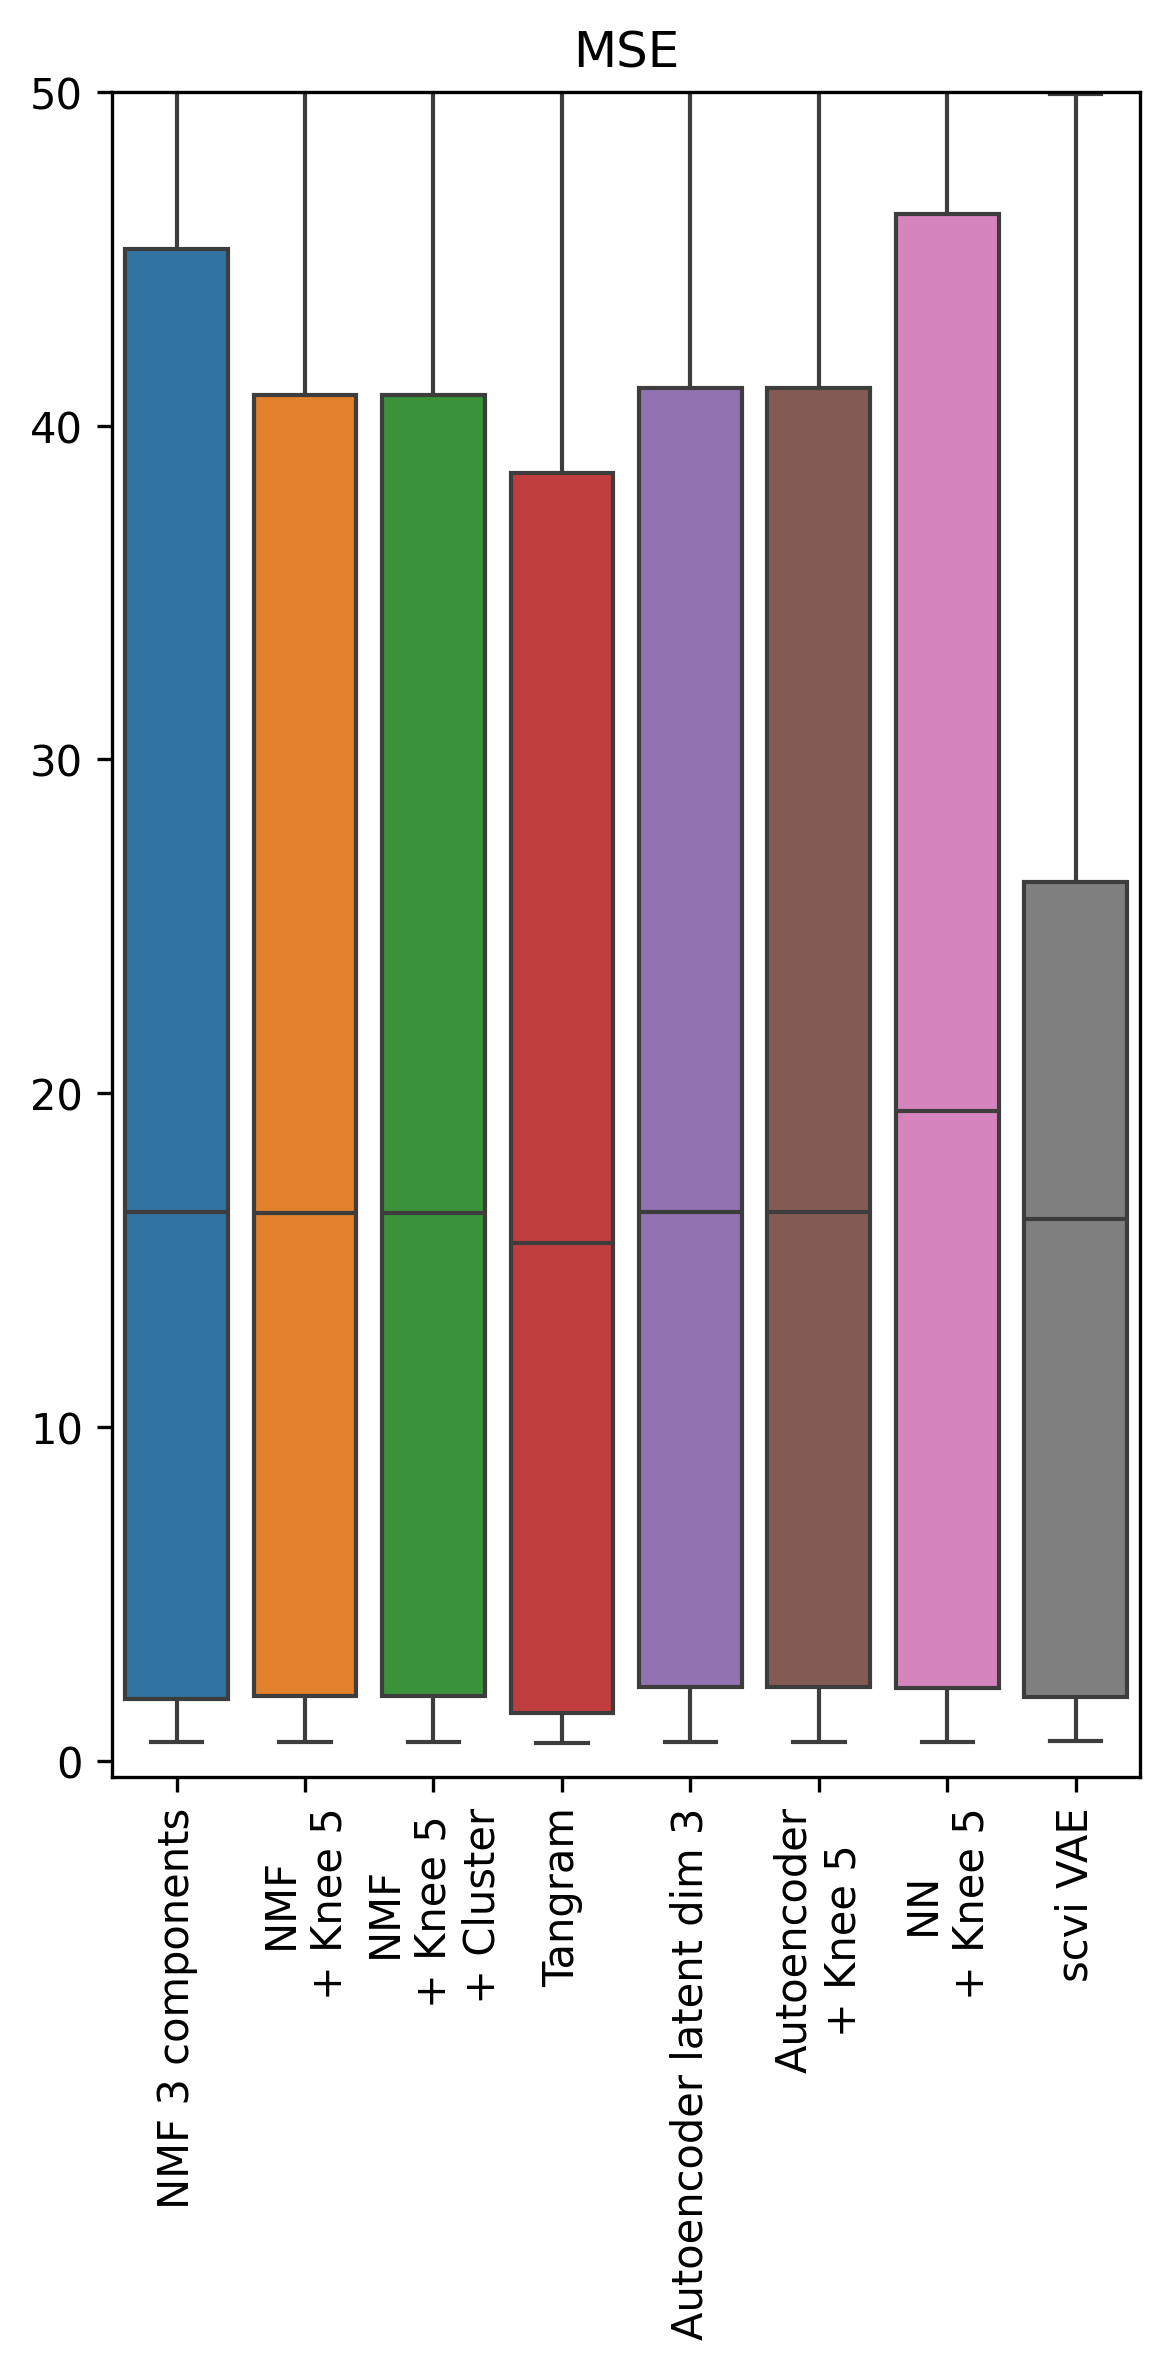

In [34]:

data = {
    method: [reconstruction_result.compute_correlation(mse) for reconstruction_result in result]
    for method, result in results.items()
}

# Create the boxplot
plt.figure(figsize=(0.5 * len(results), 8), dpi=300)
sns.boxplot(data=data)

# Format plot
plt.title("MSE")
plt.ylim(-0.5, 50)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

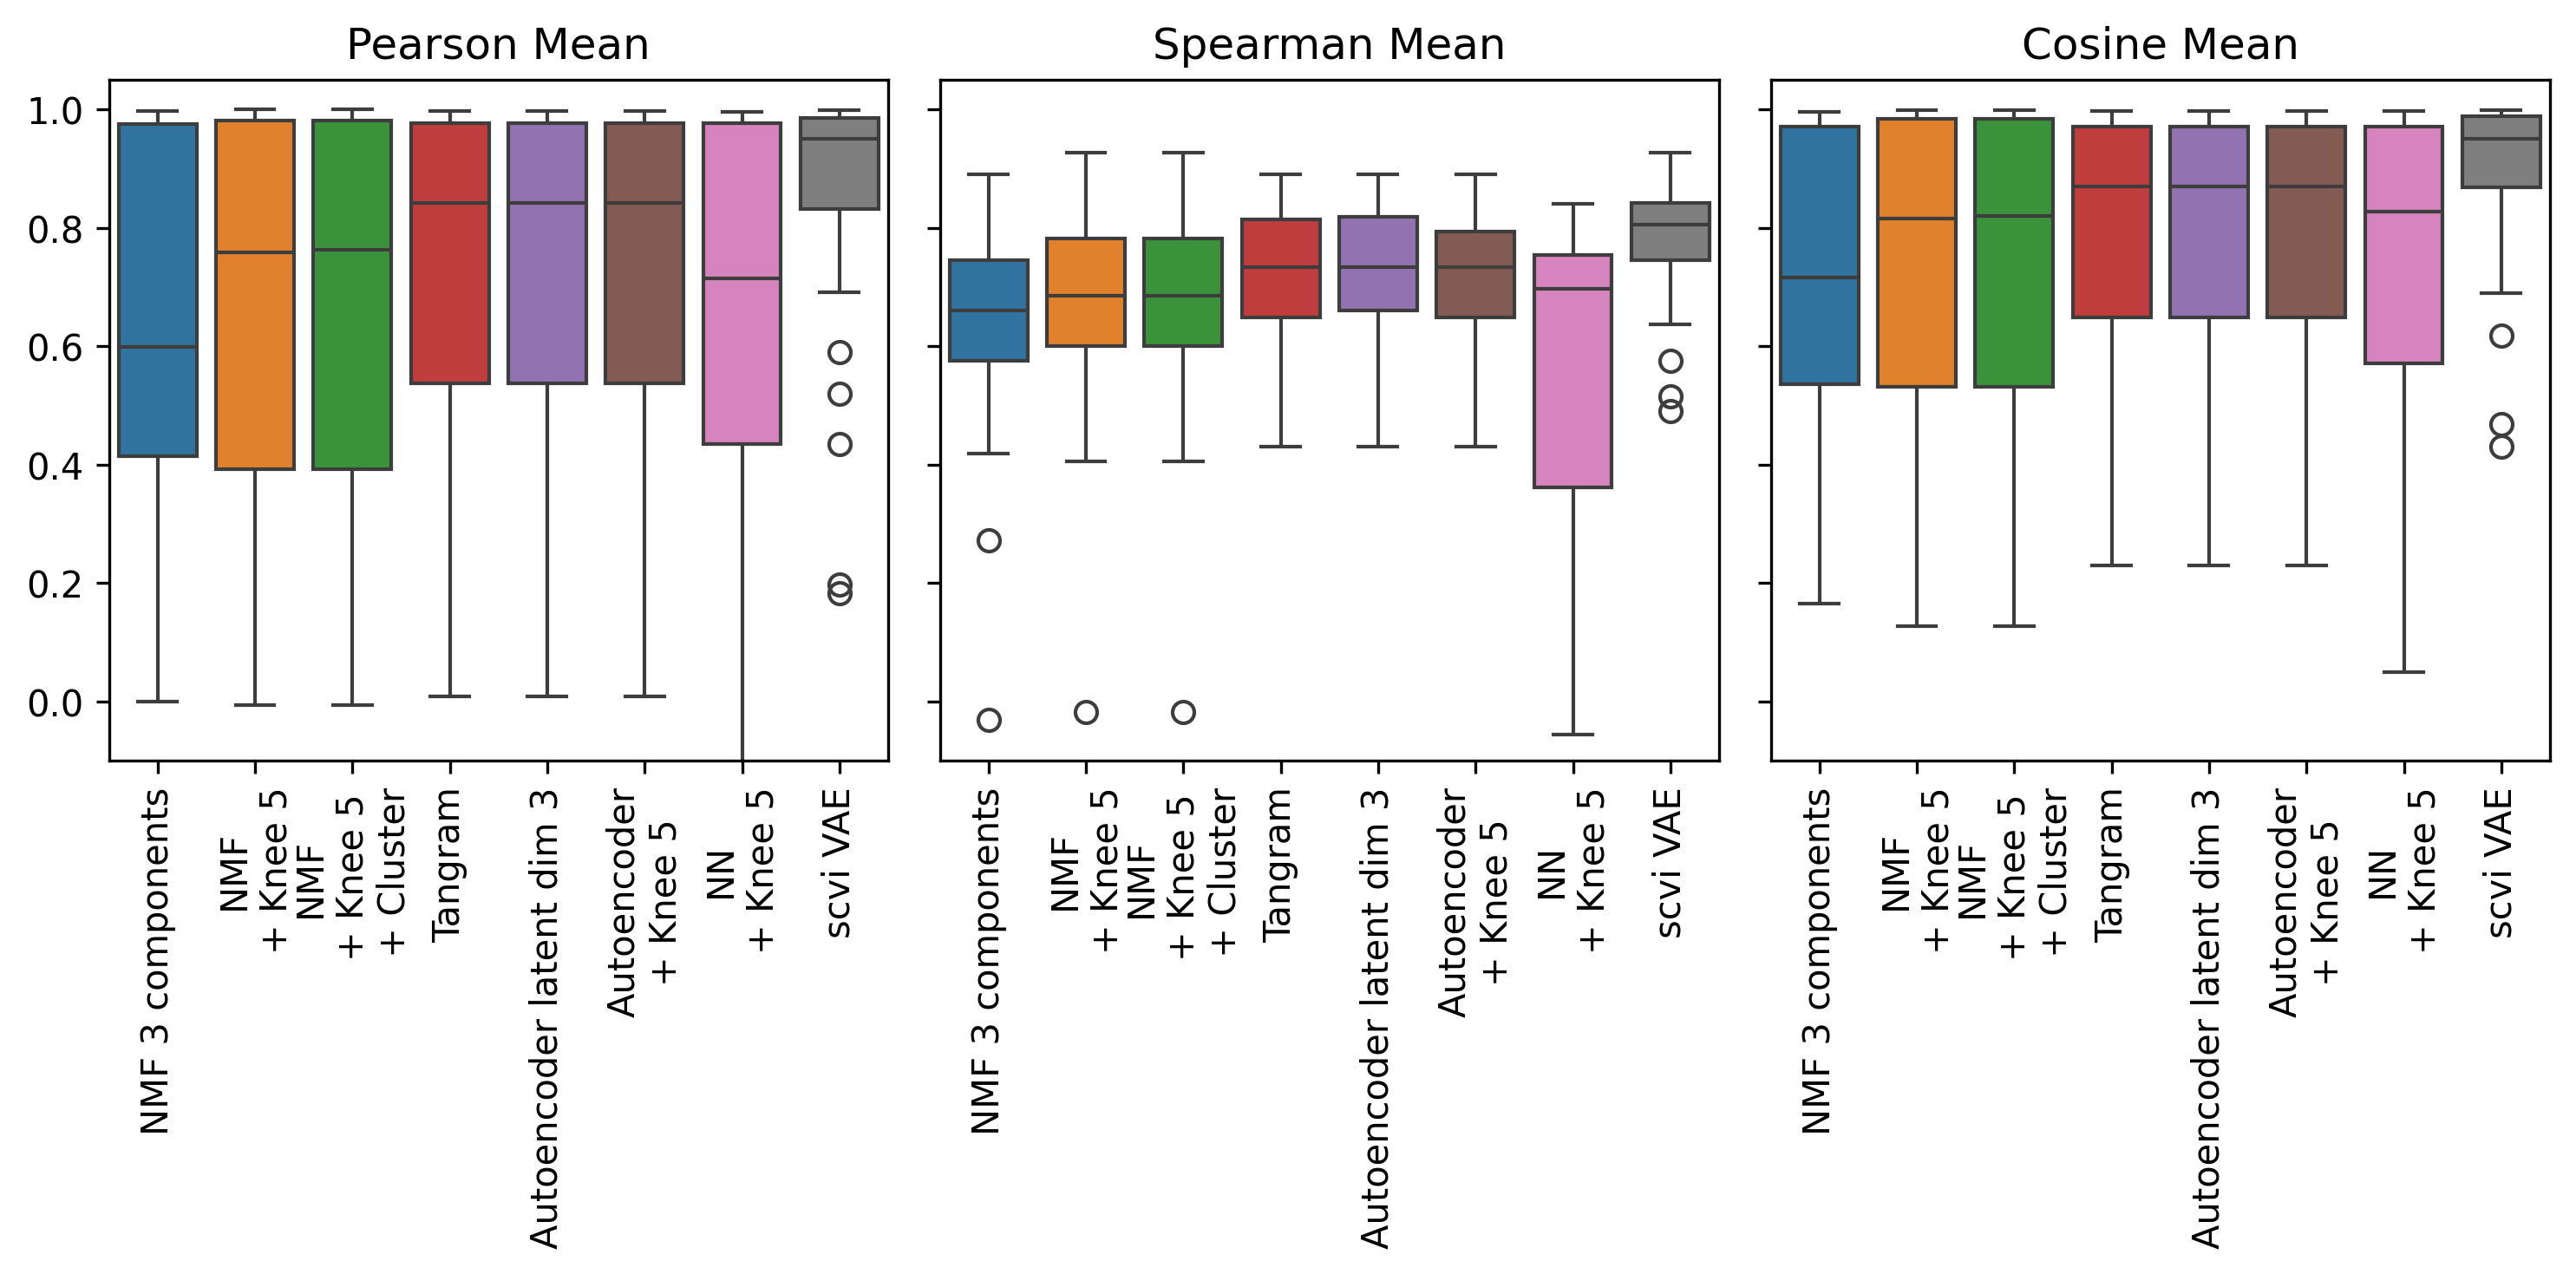

In [30]:
correlation_functions = {
    "Pearson Mean": pearsonr_mean,
    #"Pearson Log Mean": pearsonr_log_mean,
    "Spearman Mean": spearmanr_mean,
    "Cosine Mean": cosine_mean,
    #"Cosine Log Mean": cosine_log_mean,
}


fig, axes = plt.subplots(1, len(correlation_functions), figsize=(2/4.8 * len(results) * len(correlation_functions), 5), dpi=300, sharey=True)

for ax, (name, func) in zip(axes, correlation_functions.items()):
    data = {method: [reconstruction_result.compute_correlation(func) for reconstruction_result in result] for method, result in results.items()}
    sns.boxplot(data=data, ax=ax)
    ax.set_title(name)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

plt.ylim(-0.1, 1.05)
plt.tight_layout()
plt.show()

In [ ]:
assert False

AssertionError: 

  0%|          | 0/25 [1:02:41<?, ?it/s]


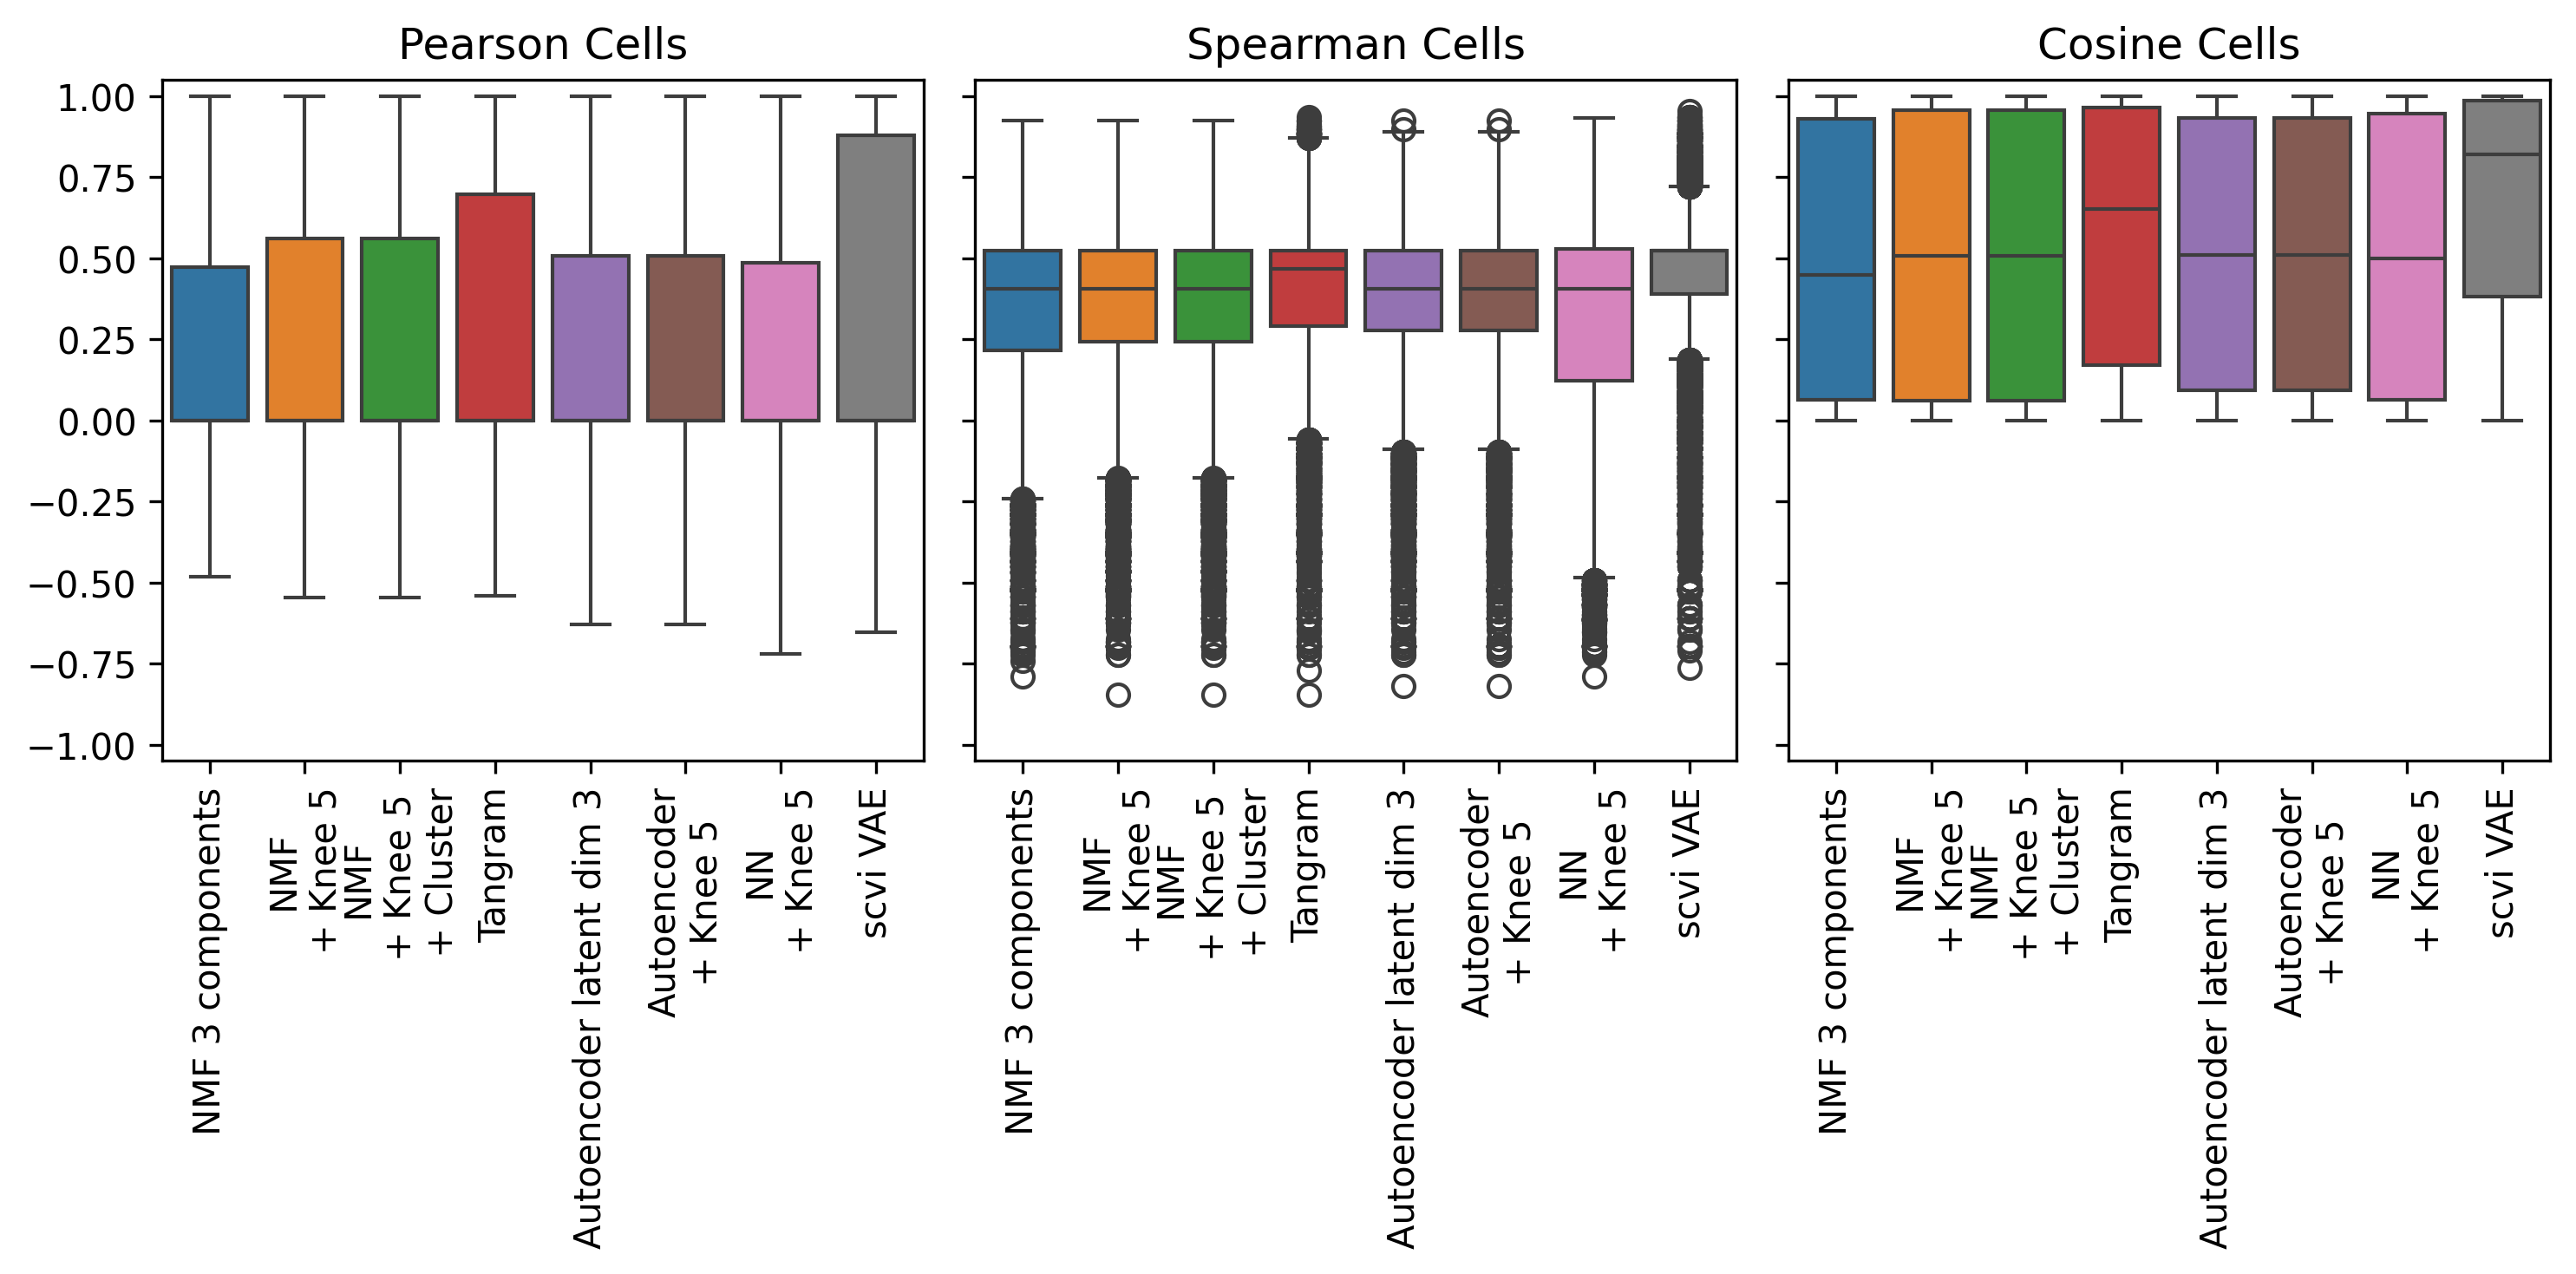

In [35]:
correlation_functions = {
    "Pearson Cells": pearsonr_cells,
    #"Pearson Log Cells": pearsonr_log_cells,
    "Spearman Cells": spearman_cells,
    "Cosine Cells": cosine_cells,
    #"Cosine Log Cells": cosine_log_cells,
}

#print(celltype)
fig, axes = plt.subplots(1, len(correlation_functions), figsize=(2/4.8 * len(results) * len(correlation_functions), 5), dpi=300, sharey=True)

for ax, (name, func) in zip(axes, correlation_functions.items()):
    data = {method: np.hstack([reconstruction_result.compute_correlation(func) for reconstruction_result in result]) for method, result in results.items()}
    sns.boxplot(data=data, ax=ax)
    ax.set_title(name)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

plt.ylim(-1.05, 1.05)
plt.tight_layout()
plt.show()

In [ ]:
assert False

AssertionError: 

In [ ]:
correlation_functions = {
    "Pearson Genes": pearsonr_genes,
    "Spearman Genes": spearman_genes,
    "Cosine Genes": cosine_genes,
}

print(celltype)
fig, axes = plt.subplots(1, len(correlation_functions), figsize=(2/3 * len(results) * len(correlation_functions), 4.5), dpi=300, sharey=True)

for ax, (name, func) in zip(axes, correlation_functions.items()):
    data = {method: np.hstack([reconstruction_result.compute_correlation(func) for reconstruction_result in result]) for method, result in results.items()}
    sns.boxplot(data=data, ax=ax)
    ax.set_title(name)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=40)

plt.ylim(-0.1, 1.05)
plt.tight_layout()
plt.show()

### NMF Kneelocator benchmark

In [ ]:
n_components_celltype = pd.Series({
    "BZE": 7,
    "Blood vasc.": 5,
    "Cycling/GC B cell": 6,
    "Glial": 8,
    "Goblet": 5,
    "Lymphatic": 5,
    "MZE": 5  ,
    "Macrophage": 7,
    "Paneth": 7,
    "Plasma": 4,
    "Rest B": 6,
    "Stem/TA": 6,
    "Stroma": 6,
    "T cell": 6,
    "TZE": 6  ,
    "Tuft": 5 ,
    "cDC/monocyte": 7,
    "neurons/enteroendocrine": 7,
    "pDC": 9  ,
})